/tmp/ipykernel_1574/905482772.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment_label', palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


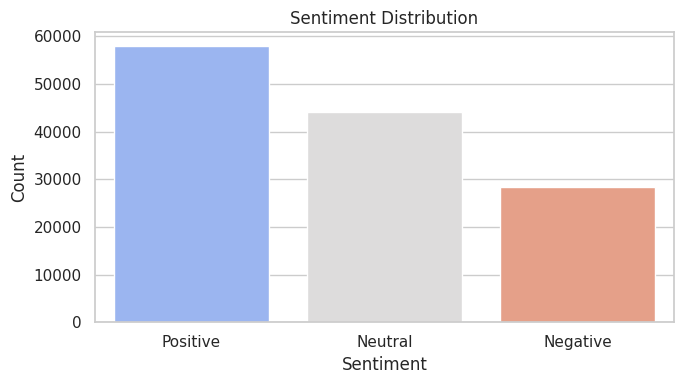

Accuracy Score: 0.7332

Classification Report:
               precision    recall  f1-score   support

          -1       0.91      0.40      0.56      5716
           0       0.88      0.67      0.76      8857
           1       0.65      0.95      0.77     11495

    accuracy                           0.73     26068
   macro avg       0.81      0.67      0.70     26068
weighted avg       0.78      0.73      0.72     26068



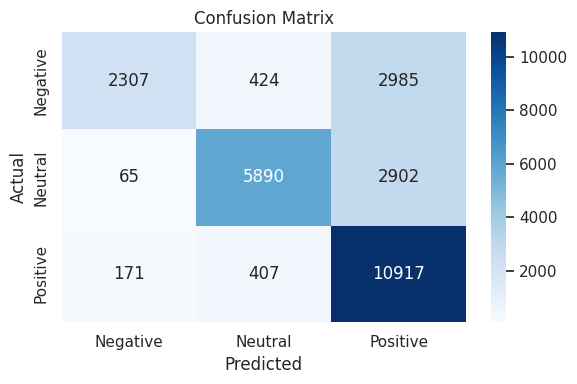

In [1]:
# ==========================================
# Task 4: Sentiment Analysis
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")

# 1. Load Dataset
df = pd.read_csv("Twitter_Data.csv")

# Clean missing values
df.dropna(inplace=True)

# 2. Text Preprocessing Function
def clean_text(text):
    text = str(text).lower()                             # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+|\#', '', text)                  # Remove mentions and hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)             # Remove numbers and special characters
    text = re.sub(r'\s+', ' ', text).strip()            # Remove extra spaces
    return text

# Apply cleaning to the text column
text_col = 'clean_text' if 'clean_text' in df.columns else df.columns[0]
df['cleaned_text'] = df[text_col].apply(clean_text)

# Find category column name
cat_col = 'category' if 'category' in df.columns else df.columns[1]

# Map numerical categories to readable labels
sentiment_map = {1: 'Positive', 0: 'Neutral', -1: 'Negative'}
df['sentiment_label'] = df[cat_col].map(sentiment_map)

# 3. Sentiment Distribution Plot
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='sentiment_label', palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 4. Feature Extraction & Model Building
X = df['cleaned_text']
y = df[cat_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Naive Bayes Classifier
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 5. Evaluation
y_pred = model.predict(X_test_tfidf)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()